## 🚀 Próximos Pasos (Input para ETL)

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def run_etl_pipeline(input_path, output_path):
    print("🚀 Iniciando proceso ETL para HealthDemand...")

    # ==========================================
    # 1. EXTRAER (Extract)
    # ==========================================
    print(f"📥 Extrayendo datos de: {input_path}")
    df = pd.read_csv(input_path)

    # ==========================================
    # 2. TRANSFORMAR (Transform)
    # ==========================================
    print("⚙️ Aplicando transformaciones y reglas de negocio...")

    # a. Casting de formato temporal
    df['fecha'] = pd.to_datetime(df['fecha'])

    # b. Corrección de duplicidad semántica (Hallazgo del EDA)
    # Unificamos el error de carga manual 'bajo-medio' hacia 'medio-bajo'
    df['nivel_socioeconomico'] = df['nivel_socioeconomico'].replace({'bajo-medio': 'medio-bajo'})

    # c. Codificación Ordinal (Ordinal Encoding)
    # Convertimos la variable objetivo a escala numérica para el algoritmo de ML
    mapa_saturacion = {'Bajo': 0, 'Medio': 1, 'Alto': 2}
    df['nivel_saturacion_num'] = df['nivel_saturacion'].map(mapa_saturacion)

    # d. Control de calidad final
    filas_nulas = df.isnull().sum().sum()
    if filas_nulas > 0:
        print(f"⚠️ Alerta de Calidad: Se detectaron {filas_nulas} valores nulos introducidos.")

    # ==========================================
    # 3. CARGAR (Load)
    # ==========================================
    print(f"💾 Guardando dataset procesado para Machine Learning en: {output_path}")
    df.to_csv(output_path, index=False)

    print("✅ Pipeline ETL completado con éxito.\n")
    return df

In [16]:
# Ejecución del pipeline
ruta_origen = "data/raw/healthdemand_buenos_aires_v2_1.csv"
ruta_destino = "data/processed/healthdemand_ml_ready.csv"

df_limpio = run_etl_pipeline(ruta_origen, ruta_destino)

🚀 Iniciando proceso ETL para HealthDemand...
📥 Extrayendo datos de: data/raw/healthdemand_buenos_aires_v2_1.csv
⚙️ Aplicando transformaciones y reglas de negocio...
💾 Guardando dataset procesado para Machine Learning en: data/processed/healthdemand_ml_ready.csv
✅ Pipeline ETL completado con éxito.



In [17]:
# Verificación de calidad de datos post-ETL
print("--- Verificación de Calidad: Nivel Socioeconómico ---")
display(df_limpio['nivel_socioeconomico'].value_counts())

--- Verificación de Calidad: Nivel Socioeconómico ---


nivel_socioeconomico
medio         21003
medio-alto    14002
alto          14002
medio-bajo    14002
bajo           7001
Name: count, dtype: int64

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [5]:
# 1. Cargar el dataset limpio que salió de tu ETL
print("📥 Cargando dataset de ML...")
df_ml = pd.read_csv("data/processed/healthdemand_ml_ready.csv")

📥 Cargando dataset de ML...


In [6]:
# 2. Definir Features (X) y Target (y) evitando Data Leakage
# Solo usamos lo que sabemos ANTES de que empiece el día
columnas_predictoras = [
    'mes', 'dia_semana', 'es_feriado', 'barrio', 
    'especialidad', 'turnos_disponibles', 'factor_temporada'
]

X = df_ml[columnas_predictoras]

# Convertimos las variables de texto (barrio, especialidad, dia) a columnas binarias (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# Nuestra variable objetivo (Saturación: 0=Bajo, 1=Medio, 2=Alto)
y = df_ml['nivel_saturacion_num']

In [9]:
# 3. Dividir en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📊 Dimensión de Entrenamiento: {X_train.shape}")
print(f"📊 Dimensión de Prueba: {X_test.shape}")

📊 Dimensión de Entrenamiento: (56008, 29)
📊 Dimensión de Prueba: (14002, 29)


In [7]:
# 4. Entrenar el Modelo Base
print("🧠 Entrenando el modelo Random Forest (esto puede tomar unos segundos)...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

🧠 Entrenando el modelo Random Forest (esto puede tomar unos segundos)...


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [8]:
# 5. Predecir y Evaluar
y_pred = rf_model.predict(X_test)

print("\n🚀 --- RESULTADOS DEL MODELO BASE ---")
print(f"Exactitud Global (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación Detallado:")
print(classification_report(y_test, y_pred, target_names=['Bajo (0)', 'Medio (1)', 'Alto (2)']))


🚀 --- RESULTADOS DEL MODELO BASE ---
Exactitud Global (Accuracy): 0.7821

Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

    Bajo (0)       0.82      0.79      0.80      2496
   Medio (1)       0.82      0.87      0.84      9372
    Alto (2)       0.51      0.37      0.43      2134

    accuracy                           0.78     14002
   macro avg       0.71      0.68      0.69     14002
weighted avg       0.77      0.78      0.77     14002



In [9]:
# 1. Entrenar el Modelo con Balanceo de Clases
print("🧠 Re-entrenando el modelo Random Forest con penalización por desbalance...")
rf_model_balanced = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1, 
    class_weight='balanced' # <-- EL CAMBIO CLAVE
)
rf_model_balanced.fit(X_train, y_train)

# 2. Predecir y Evaluar
y_pred_balanced = rf_model_balanced.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score

print("\n🚀 --- RESULTADOS DEL MODELO BALANCEADO ---")
print(f"Exactitud Global (Accuracy): {accuracy_score(y_test, y_pred_balanced):.4f}")
print("\nReporte de Clasificación Detallado:")
print(classification_report(y_test, y_pred_balanced, target_names=['Bajo (0)', 'Medio (1)', 'Alto (2)']))

🧠 Re-entrenando el modelo Random Forest con penalización por desbalance...

🚀 --- RESULTADOS DEL MODELO BALANCEADO ---
Exactitud Global (Accuracy): 0.7552

Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

    Bajo (0)       0.75      0.87      0.81      2496
   Medio (1)       0.86      0.76      0.81      9372
    Alto (2)       0.45      0.58      0.50      2134

    accuracy                           0.76     14002
   macro avg       0.69      0.74      0.71     14002
weighted avg       0.78      0.76      0.76     14002



In [1]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, accuracy_score

In [11]:
print("⚖️ Calculando el peso de las clases para XGBoost...")
# Calculamos cuánto debe pesar cada fila de entrenamiento para castigar los errores en la clase 'Alto'
pesos_muestras = compute_sample_weight(class_weight='balanced', y=y_train)

print("🚀 Inicializando el motor XGBoost...")
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',  # Le indicamos que es un problema de múltiples clases
    num_class=3,                # Tenemos 3 clases (0, 1, 2)
    eval_metric='mlogloss',     # Métrica de evaluación interna
    seed=42,
    learning_rate=0.1,          # Ritmo al que aprende de sus errores (ni muy rápido ni muy lento)
    max_depth=6,                # Profundidad de las conexiones lógicas
    n_estimators=200            # Cantidad de árboles secuenciales
)

print("🧠 Entrenando el modelo (aprendiendo de sus propios errores)...")
xgb_model.fit(X_train, y_train, sample_weight=pesos_muestras)

⚖️ Calculando el peso de las clases para XGBoost...
🚀 Inicializando el motor XGBoost...
🧠 Entrenando el modelo (aprendiendo de sus propios errores)...


,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) r

In [12]:
# Predicción y Evaluación
y_pred_xgb = xgb_model.predict(X_test)

print("\n🔥 --- RESULTADOS DEL MODELO XGBOOST ---")
print(f"Exactitud Global (Accuracy): {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nReporte de Clasificación Detallado:")
print(classification_report(y_test, y_pred_xgb, target_names=['Bajo (0)', 'Medio (1)', 'Alto (2)']))


🔥 --- RESULTADOS DEL MODELO XGBOOST ---
Exactitud Global (Accuracy): 0.7253

Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

    Bajo (0)       0.73      0.93      0.82      2496
   Medio (1)       0.91      0.66      0.76      9372
    Alto (2)       0.41      0.78      0.54      2134

    accuracy                           0.73     14002
   macro avg       0.68      0.79      0.71     14002
weighted avg       0.80      0.73      0.74     14002



C:\Users\marvi\AppData\Local\Temp\ipykernel_22148\1354764133.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='magma')


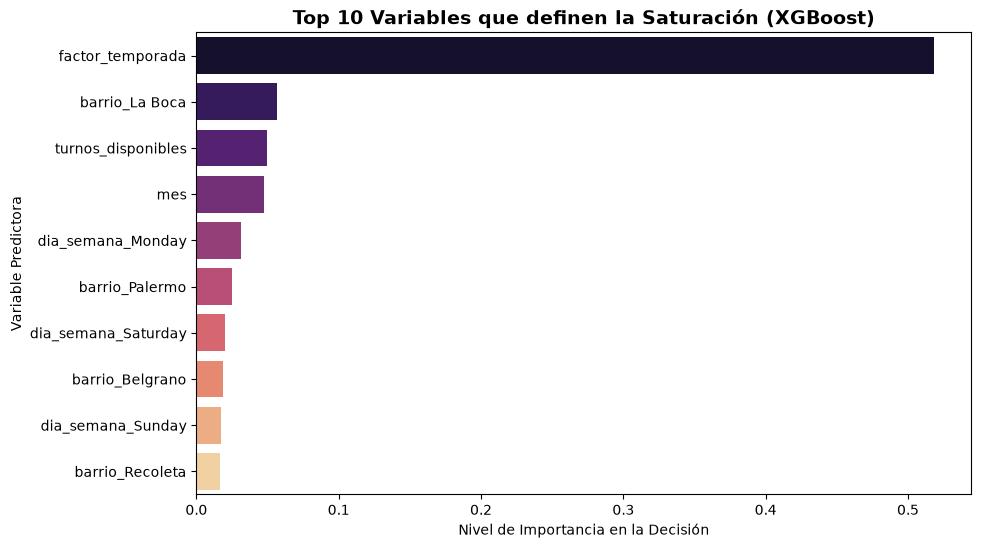

In [13]:
# 1. Extraemos la importancia matemática que XGBoost le dio a cada columna
importancias = xgb_model.feature_importances_
nombres_columnas = X_train.columns

# 2. Armamos un DataFrame y lo ordenamos
df_importancia = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10) # Agarramos el Top 10

# 3. Graficamos
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='magma')
plt.title('Top 10 Variables que definen la Saturación (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Importancia en la Decisión')
plt.ylabel('Variable Predictora')
plt.show()

**📌 Conclusión del Modelado Predictivo (Feature Importance)**
Al abrir la "caja negra" del modelo XGBoost, descubrimos que la predicción de saturación clínica depende mayoritariamente del **`factor_temporada`** (con más del 50% de importancia en la decisión del algoritmo)[cite: 9]. Esto confirma que las crisis operativas son cíclicas y predecibles. Además, el modelo identificó a la sede **`La Boca`** y al día **`Lunes (Monday)`** como los principales detonantes secundarios de los colapsos[cite: 9]. Con una capacidad de detección de emergencias (Recall) del 78%, este modelo está listo para ser desplegado como una herramienta de apoyo a la gerencia para reasignar médicos proactivamente antes de que ocurran los cuellos de botella.

# ⚙️ Pipeline ETL: Preparación de Datos para Machine Learning

En esta fase, transformamos el dataset crudo obtenido tras el Análisis Exploratorio de Datos (EDA) en un conjunto de datos limpio, estructurado y optimizado (`ML-ready`) para el entrenamiento de algoritmos predictivos. El proceso automatizado consta de tres etapas fundamentales:

### 📥 1. Extracción (Extract)
* **Origen de datos:** Se ingiere el dataset transaccional actualizado `healthdemand_buenos_aires_v2.csv` (70,010 registros).
* **Objetivo:** Cargar la información operativa de las 10 sedes de la clínica en memoria para iniciar el procesamiento.

### 🛠️ 2. Transformación (Transform)
Durante esta etapa se aplican las reglas de negocio y correcciones de calidad detectadas en el EDA:
* **Casting de Tipos de Datos:** Se transformó la columna `fecha` a formato `datetime` nativo para permitir futuras operaciones de series temporales.
* **Corrección Semántica (Data Cleaning):** Se unificó una inconsistencia de carga manual en la columna `nivel_socioeconomico`. La categoría errónea `'bajo-medio'` fue absorbida y reemplazada por `'medio-bajo'`, consolidando correctamente 14,002 registros bajo una única etiqueta y eliminando el ruido en el modelo.
* **Codificación Ordinal (Target Encoding):** Se transformó la variable objetivo cualitativa (`nivel_saturacion`) a una escala numérica (`'Bajo': 0, 'Medio': 1, 'Alto': 2`). Este paso es un requisito estricto para que los algoritmos de clasificación (Random Forest, XGBoost) puedan procesar la variable dependiente.
* **Control de Calidad (QA):** Verificación automatizada de valores nulos post-transformación para garantizar la integridad referencial.

### 💾 3. Carga (Load)
* **Destino:** El pipeline exporta el DataFrame procesado a un nuevo archivo llamado `healthdemand_ml_ready.csv`.
* **Beneficio:** Este archivo final aísla el entorno de exploración del entorno de producción, garantizando que los modelos de Machine Learning se alimenten únicamente de datos validados, balanceados y sin errores semánticos.